<a href="https://colab.research.google.com/github/canunz/EV3_outfits/blob/main/exploracion_weatherAUS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploración del Dataset — weatherAUS
BIY7121 Minería de Datos — DuocUC


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('weatherAUS.csv', on_bad_lines='skip', engine='python')
print(f'Filas: {df.shape[0]}, Columnas: {df.shape[1]}')
df.head()

Filas: 168829, Columnas: 24


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0,No
1,2008-12-02,Albury,7.4,25.1,0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0,No
2,2008-12-03,Albury,12.9,25.7,0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0,No
3,2008-12-04,Albury,9.2,28.0,0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1,No
4,2008-12-05,Albury,17.5,32.3,1,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


## 1. Tipos de datos

In [7]:
df.dtypes

,0
Date,object
Location,object
MinTemp,object
MaxTemp,float64
Rainfall,object
Evaporation,float64
Sunshine,float64
WindGustDir,object
WindGustSpeed,float64
WindDir9am,object


## 2. Valores nulos por columna

In [8]:
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, '% del total': pct})
resumen_nulos[resumen_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)

,Nulos,% del total
Sunshine,80235,47.52
Evaporation,71386,42.28
Cloud3pm,68517,40.58
Cloud9am,64458,38.18
Pressure9am,18127,10.74
Pressure3pm,18098,10.72
WindDir9am,11336,6.71
WindGustDir,9670,5.73
WindGustSpeed,9574,5.67
Humidity3pm,4506,2.67


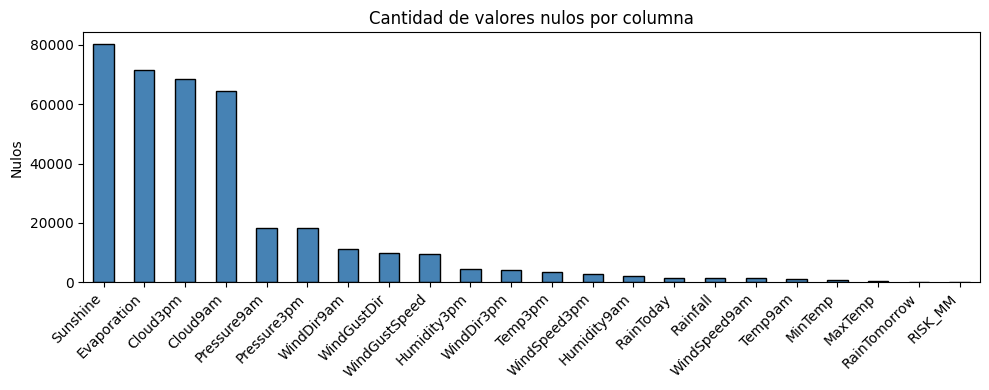

In [9]:
# Gráfico de nulos
cols_con_nulos = nulos[nulos > 0].sort_values(ascending=False)
plt.figure(figsize=(10, 4))
cols_con_nulos.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Cantidad de valores nulos por columna')
plt.ylabel('Nulos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Variable objetivo — RainTomorrow

RainTomorrow
No     131501
Yes     37326
Name: count, dtype: int64

RainTomorrow
No     77.89
Yes    22.11
Name: proportion, dtype: float64


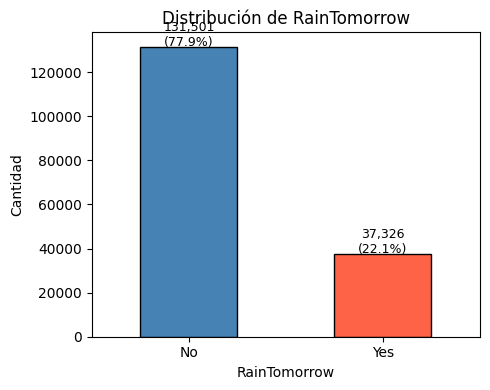

In [10]:
conteo = df['RainTomorrow'].value_counts()
pct_rt = df['RainTomorrow'].value_counts(normalize=True) * 100
print(conteo)
print()
print(pct_rt.round(2))

plt.figure(figsize=(5, 4))
conteo.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Distribución de RainTomorrow')
plt.xlabel('RainTomorrow')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
for i, v in enumerate(conteo):
    plt.text(i, v + 500, f'{v:,}\n({pct_rt.iloc[i]:.1f}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 4. Estadísticas descriptivas — variables numéricas

In [11]:
num_cols = df.select_dtypes(include='number').columns.tolist()
df[num_cols].describe().round(2)

,MaxTemp,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am
count,168468.00,97443.00,88594.00,159255.00,167404.00,166112.00,166910.00,164323.00,150702.00,150731.00,104371.00,100312.00,167874.00
mean,23.54,5.57,7.74,40.02,14.01,18.50,67.93,50.68,1017.38,1014.93,4.34,4.42,17.24
std,7.25,4.14,3.75,13.43,8.74,8.58,19.49,20.95,7.16,7.58,2.89,2.73,6.63
min,-4.80,0.00,0.00,6.00,0.00,0.00,0.00,0.00,980.50,0.00,0.00,0.00,-7.20
25%,18.10,2.80,5.10,31.00,7.00,13.00,56.00,36.00,1012.60,1010.00,1.00,2.00,12.40
50%,22.90,4.80,8.60,39.00,13.00,19.00,69.00,51.00,1017.30,1014.90,5.00,5.00,16.90
75%,28.80,7.60,10.70,48.00,19.00,24.00,82.00,65.00,1022.20,1019.80,7.00,7.00,21.90
max,48.10,145.00,14.50,135.00,130.00,87.00,100.00,100.00,1041.00,1039.60,9.00,19.20,40.20


## 5. Distribución de variables numéricas clave

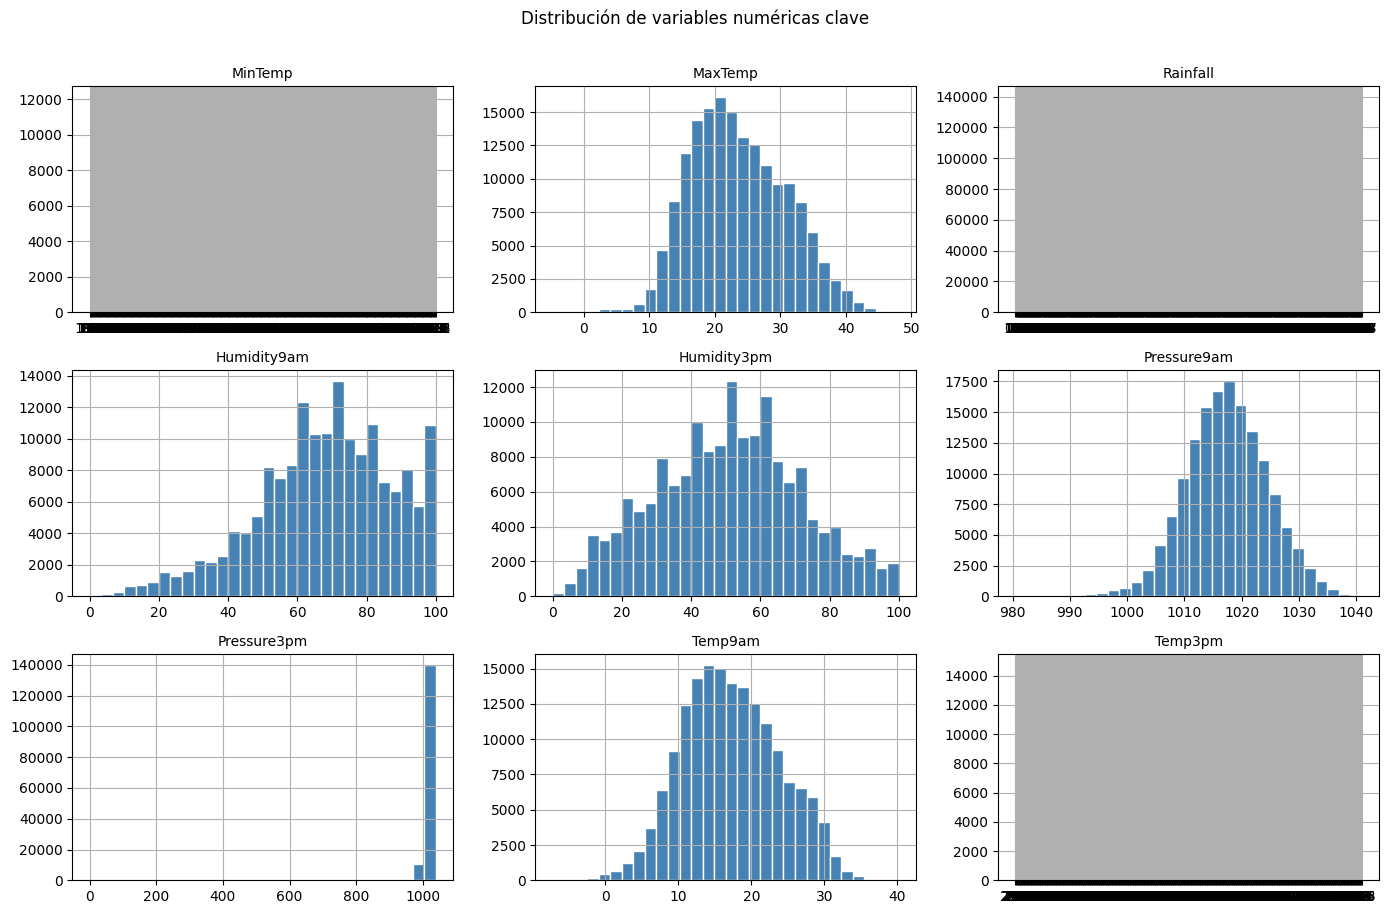

In [12]:
vars_clave = ['MinTemp', 'MaxTemp', 'Rainfall', 'Humidity9am', 'Humidity3pm',
              'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm']

fig, axes = plt.subplots(3, 3, figsize=(14, 9))
for i, col in enumerate(vars_clave):
    ax = axes[i//3][i%3]
    df[col].dropna().hist(ax=ax, bins=30, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
plt.suptitle('Distribución de variables numéricas clave', y=1.01)
plt.tight_layout()
plt.show()

## 6. Variables numéricas vs RainTomorrow

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
for i, col in enumerate(vars_clave):
    ax = axes[i//3][i%3]
    sns.boxplot(data=df, x='RainTomorrow', y=col, ax=ax,
                palette=['steelblue', 'tomato'])
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
plt.suptitle('Variables numéricas vs RainTomorrow', y=1.01)
plt.tight_layout()
plt.show()

## 7. Variables categóricas

In [ ]:
# Ubicaciones únicas
print(f'Ubicaciones únicas: {df["Location"].nunique()}')
print(df['Location'].value_counts())

In [ ]:
# RainToday vs RainTomorrow
tabla_cruce = pd.crosstab(df['RainToday'], df['RainTomorrow'], margins=True)
print(tabla_cruce)

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='RainToday', hue='RainTomorrow',
              palette=['steelblue', 'tomato'])
plt.title('RainToday vs RainTomorrow')
plt.tight_layout()
plt.show()

## 8. Detección de outliers — IQR

In [ ]:
# Cálculo de outliers con método IQR para variables numéricas
resultados_iqr = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_out = df[(df[col] < lim_inf) | (df[col] > lim_sup)][col].count()
    pct_out = round(n_out / df[col].count() * 100, 2)
    resultados_iqr.append({
        'Variable': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'Lim inf': round(lim_inf, 2),
        'Lim sup': round(lim_sup, 2),
        'Outliers': n_out,
        '% outliers': pct_out
    })

pd.DataFrame(resultados_iqr).sort_values('Outliers', ascending=False)

In [ ]:
# Boxplots de variables con más outliers
vars_out = ['Rainfall', 'WindGustSpeed', 'Evaporation', 'RISK_MM']
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i, col in enumerate(vars_out):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
plt.suptitle('Boxplots — variables con más outliers')
plt.tight_layout()
plt.show()

## 9. Correlación entre variables numéricas

In [ ]:
# Convertir RainTomorrow a número para incluirla en la correlación
df_corr = df.copy()
df_corr['RainTomorrow_num'] = (df_corr['RainTomorrow'] == 'Yes').astype(int)

corr = df_corr[num_cols + ['RainTomorrow_num']].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de correlación — variables numéricas + RainTomorrow')
plt.tight_layout()
plt.show()

In [ ]:
# Correlación específica con RainTomorrow
corr_target = df_corr[num_cols + ['RainTomorrow_num']].corr()['RainTomorrow_num'].drop('RainTomorrow_num')
corr_target = corr_target.sort_values(key=abs, ascending=False)

colores = ['tomato' if v > 0 else 'steelblue' for v in corr_target]
plt.figure(figsize=(8, 5))
plt.barh(corr_target.index, corr_target.values, color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlación de variables numéricas con RainTomorrow\n(rojo = sube el riesgo, azul = lo baja)')
plt.tight_layout()
plt.show()
print(corr_target.round(3))

## 10. Resumen final — datos reales del dataset

In [ ]:
print('=== RESUMEN DATASET weatherAUS ===')
print(f'Total registros     : {df.shape[0]:,}')
print(f'Total columnas      : {df.shape[1]}')
print(f'Ubicaciones únicas  : {df["Location"].nunique()}')
print()
print('--- Variable objetivo RainTomorrow ---')
for val, cnt in df['RainTomorrow'].value_counts().items():
    pct = cnt / len(df) * 100
    print(f'  {val}: {cnt:,} ({pct:.1f}%)')
print()
print('--- Top 5 columnas con más nulos ---')
top5 = nulos[nulos > 0].sort_values(ascending=False).head(5)
for col, n in top5.items():
    print(f'  {col}: {n:,} nulos ({n/len(df)*100:.1f}%)')